In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister


Bell state |Φ+>


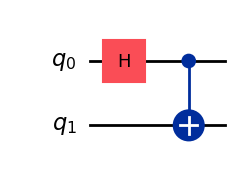

In [3]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

print("Bell state |Φ+>")
display(bell.draw("mpl"))


Teleportation using |Φ+>


/tmp/ipykernel_550/950104359.py:21: DeprecationWarning: The method ``qiskit.circuit.instructionset.InstructionSet.c_if()`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  tele.x(qr[2]).c_if(cr, 1)   # if bits = 01
/tmp/ipykernel_550/950104359.py:22: DeprecationWarning: The method ``qiskit.circuit.instructionset.InstructionSet.c_if()`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  tele.z(qr[2]).c_if(cr, 2)   # if bits = 10
/tmp/ipykernel_550/950104359.py:23: DeprecationWarning: The method ``qiskit.circuit.instructionset.InstructionSet.c_if()`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  tele.x(qr[2]).c_if(cr, 3)   # if bits = 11
/tmp/ipykernel_550/950104359.py:24: DeprecationWarning: The method ``qiskit.circuit.instructionset.InstructionSet.c_if()`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  tele.z(qr[2]).c_if(cr, 3)


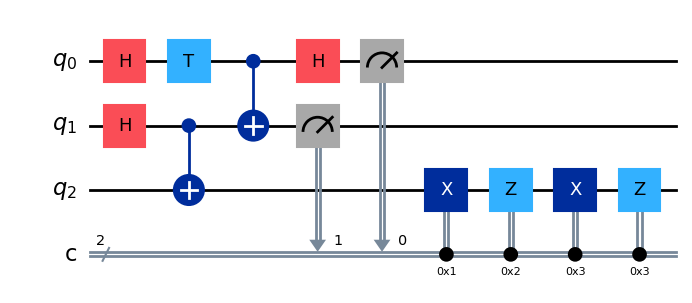

In [4]:
qr = QuantumRegister(3, 'q')
cr = ClassicalRegister(2, 'c')
tele = QuantumCircuit(qr, cr)

# --- 1) Prepare some state on qubit 0 (example) ---
tele.h(qr[0])
tele.t(qr[0])

# --- 2) Create Bell state |Φ+> between q1 and q2 ---
tele.h(qr[1])
tele.cx(qr[1], qr[2])

# --- 3) Bell measurement on q0 and q1 ---
tele.cx(qr[0], qr[1])
tele.h(qr[0])

tele.measure(qr[0], cr[0])
tele.measure(qr[1], cr[1])

# --- 4) Conditional corrections ---
tele.x(qr[2]).c_if(cr, 1)   # if bits = 01
tele.z(qr[2]).c_if(cr, 2)   # if bits = 10
tele.x(qr[2]).c_if(cr, 3)   # if bits = 11
tele.z(qr[2]).c_if(cr, 3)

print("Teleportation using |Φ+>")
display(tele.draw("mpl"))
